# Gene isoform structures

Plot **all** PacBio isoforms of a gene (recollapsed molecule-level models) as exon/intron diagrams, alongside the GENCODE v41 reference transcripts. **Set the gene in the Parameters cell below** — everything downstream derives from it, so the notebook works for any gene (CDKN2A is the default example).

- Exon coordinates come from the **global** recollapsed collapse GFF (`pacbio/recollapsed/pooled/collapse.gff`), which holds exactly **one canonical structure per PB id**. (Do *not* use the per-tissue `collapse/{tissue}/collapse.recollapsed.sorted.gff` files: those re-collapse with tissue-specific exon boundaries, so the same PB id has different structures across tissues — merging them produces chimeric models.)
- Gene → PB-isoform mapping comes from the SQANTI3 classification (`associated_gene` = ENSG).
- Optional reference **protein colouring** comes from a per-gene Ensembl gene-summary export (`csvs/transcripts-Summary-Homo_sapiens_Gene_Summary_<ENSG>.csv`); if none exists for the chosen gene, the reference is drawn in flat grey. CDKN2A example: ENSG00000147889 (chr9, minus strand).

In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import re, glob, subprocess, tempfile, os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.legend as _mlegend
from matplotlib.patches import Patch, Rectangle

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


In [2]:
# preferred plot formatting
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
# Mathtext (anything in $...$) otherwise falls back to DejaVu Sans, so Greek letters,
# superscripts and subscripts render in a different family from the surrounding Arial.
# "custom" + the four Arial families keeps the whole figure in one typeface.
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'

TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0

plt.rcParams.update({
    "font.size": 6, "axes.titlesize": 6, "axes.labelsize": 6,
    "xtick.labelsize": 6, "ytick.labelsize": 6,
    "legend.fontsize": 6, "legend.title_fontsize": 6,
    "legend.labelspacing": 0.1, "legend.borderpad": 0.3, "legend.handletextpad": 0.2,
    "figure.titlesize": 6,
    "axes.labelweight": "bold", "axes.titleweight": "bold", "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN, "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD, "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD, "axes.titlepad": PANEL_TITLE_PAD,
    "savefig.dpi": 300, "savefig.bbox": "tight",
})

# Legend-title weight has no rcParam -> make every legend title bold by default.
if not getattr(_mlegend.Legend, "_bold_title_patched", False):
    _orig_set_title = _mlegend.Legend.set_title
    def _bold_set_title(self, title, prop=None):
        res = _orig_set_title(self, title, prop=prop)
        self.get_title().set_fontweight("bold")
        return res
    _mlegend.Legend.set_title = _bold_set_title
    _mlegend.Legend._bold_title_patched = True

In [3]:
# === Parameters: set the gene here; every section below derives from it ===
GENE      = "CDKN2A"     # <- change to any HGNC gene symbol and re-run the notebook
MIN_CELLS = 5            # expression filter (section 3): isoforms detected in >= MIN_CELLS cells
FIG_DIR   = "./figures"
CSVS_DIR  = "./../csvs"

# filesystem-safe slug for output filenames, e.g. "CDKN2A" -> "cdkn2a"
GENE_SLUG = re.sub(r"[^0-9A-Za-z]+", "_", GENE).strip("_").lower()
def fig_path(suffix):
    return figpath(f"{GENE_SLUG}_{suffix}.pdf")

In [10]:
REF_GTF    = "/oak/stanford/groups/quake/mmantri/group.quake/references/gencode_GRCh38.p13_release41/gencode.v41.annotation.gtf"
CLASS_CSV  = "./../csvs/all_samples_recollapsed_sqanti3_classification.csv"
# Canonical GLOBAL recollapsed models: exactly one structure per PB.X.Y.
# Do NOT glob the per-tissue collapse.recollapsed.sorted.gff files -- those re-collapse with
# tissue-specific exon boundaries, so the SAME id has DIFFERENT structures across tissues, and
# appending them all (as _parse_exons does) yields chimeric, smeared models. The pooled
# collapse.gff holds the single global model that the SQANTI3 classification ids refer to.
GLOBAL_GFF = "./../pacbio/recollapsed/pooled/collapse.gff"


def _parse_exons(lines, keep=None):
    """Parse GTF/GFF exon lines -> {tid: {'chrom','strand','name','exons':[(s,e)]}}."""
    tx = {}
    for line in lines:
        if not line or line[0] == "#":
            continue
        f = line.rstrip("\n").split("\t")
        if len(f) < 9 or f[2] != "exon":
            continue
        m = re.search(r'transcript_id "([^"]+)"', f[8])
        if not m:
            continue
        tid = m.group(1)
        if keep is not None and tid not in keep:
            continue
        d = tx.setdefault(tid, {"chrom": f[0], "strand": f[6], "name": tid, "exons": []})
        d["exons"].append((int(f[3]), int(f[4])))
        nm = re.search(r'transcript_name "([^"]+)"', f[8])
        if nm:
            d["name"] = nm.group(1)
    for d in tx.values():
        d["exons"].sort()
    return tx


def load_reference_models(gene):
    """GENCODE reference transcripts + the gene's ENSG(s). Fast (one grep of the GTF)."""
    ref_lines = subprocess.run(["grep", f'gene_name "{gene}"', REF_GTF],
                               capture_output=True, text=True).stdout.splitlines()
    ensg = {re.search(r'gene_id "([^".]+)', l).group(1) for l in ref_lines if 'gene_id "' in l}
    ref = _parse_exons(ref_lines)
    return ref, ensg


def load_pb_models(gene, ensg=None):
    """PacBio isoforms of a gene from the GLOBAL recollapsed collapse.gff (one canonical
    structure per PB.X.Y). Fast: greps a single file with exact transcript-id patterns."""
    if ensg is None:
        _, ensg = load_reference_models(gene)
    cl = pd.read_csv(CLASS_CSV, usecols=["isoform", "associated_gene", "structural_category", "strand"])
    cl["ensg"] = cl["associated_gene"].astype(str).str.split(".").str[0]
    sub = cl[cl["ensg"].isin(ensg)]
    pb_ids = set(sub["isoform"])
    cat = dict(zip(sub["isoform"], sub["structural_category"]))

    # Exact patterns ('transcript_id "PB.X.Y"') avoid substring over-matching (PB.1.1 vs PB.1.10).
    with tempfile.NamedTemporaryFile("w", suffix=".txt", delete=False) as tf:
        tf.write("\n".join(f'transcript_id "{i}"' for i in pb_ids))
        idfile = tf.name
    hits = subprocess.run(["grep", "-hF", "-f", idfile, GLOBAL_GFF],
                          capture_output=True, text=True).stdout.splitlines()
    os.unlink(idfile)
    pb = _parse_exons(hits, keep=pb_ids)
    return pb, cat

In [11]:
# color by SQANTI3 structural category (PacBio isoforms)
CAT_ORDER = ["full-splice_match", "incomplete-splice_match", "novel_in_catalog",
             "novel_not_in_catalog", "genic", "fusion", "antisense", "intergenic",
             "genic_intron", "moreJunctions"]
CAT_COL = {"full-splice_match": "#4c72b0", "incomplete-splice_match": "#8fbede",
           "novel_in_catalog": "#dd8452", "novel_not_in_catalog": "#c44e52",
           "genic": "#937860", "fusion": "#8172b3", "antisense": "#ccb974",
           "intergenic": "#64b5cd", "genic_intron": "#da8bc3", "moreJunctions": "#999999"}
REF_COL = "0.35"


def plot_gene_isoforms(gene, ref, pb, cat, row=0.05, exon_h=0.7, figsize=None,
                       lw=0.4, arrow_lw=None, arrow_size=3.0, save=None, title=None,
                       ref_group=None, ref_palette=None, show_direction=True, intron_arrow_bp=5000):
    """ref_group: optional {ENST(version-stripped) -> label} to colour reference rows
    (e.g. protein ID). If given, reference is coloured by that group and shown in the legend.
    show_direction: draw 5'->3' (TSS -> stop codon) direction chevrons along the intronic
    regions every `intron_arrow_bp` bp, pointing in the strand direction (+ -> right, - -> left).
    lw: stroke width (points) of the intron backbone line AND, unless arrow_lw is
        given, of the 5'->3' direction chevrons -- one knob for overall line/arrow
        thickness.
    arrow_lw: optional override for the chevron stroke width only (defaults to lw).
    arrow_size: chevron marker size (points). Raise alongside lw, otherwise a thick
        stroke on a small caret reads as a blob.
    figsize: (width, height) in inches. Default None -> auto-size as
        (3.0, row * n_rows) so that plots with many isoforms stay legible.
        NOTE passing figsize overrides `row` completely: `row` exists only to set the
        per-isoform height of the auto-sized figure, it has no other effect."""
    _alw = lw if arrow_lw is None else arrow_lw
    order = {c: i for i, c in enumerate(CAT_ORDER)}
    ref_ids = sorted(ref, key=lambda t: ref[t]["exons"][0][0])
    pb_ids = sorted(pb, key=lambda t: (order.get(cat.get(t), 99), pb[t]["exons"][0][0]))
    rows = ref_ids + pb_ids
    models = {**ref, **pb}
    n = len(rows)

    # reference colour map: by group (e.g. protein ID) if provided, else flat grey
    def _rlabel(tid):
        return (ref_group or {}).get(tid.split(".")[0], "No protein")
    ref_labels = sorted({_rlabel(t) for t in ref_ids}, key=lambda x: (x == "No protein", x))
    if ref_group is not None and ref_palette is None:
        base = list(matplotlib.colormaps["tab10"].colors)
        non_np = [l for l in ref_labels if l != "No protein"]
        ref_palette = {lab: base[i % len(base)] for i, lab in enumerate(non_np)}
        ref_palette["No protein"] = "0.7"

    def ref_color(tid):
        return REF_COL if ref_group is None else ref_palette[_rlabel(tid)]

    fig, ax = plt.subplots(figsize=(3.0, row * n) if figsize is None else figsize)
    for i, tid in enumerate(rows):
        ex = models[tid]["exons"]
        lo, hi = ex[0][0], ex[-1][1]
        is_ref = tid in ref
        color = ref_color(tid) if is_ref else CAT_COL.get(cat.get(tid), "#999999")
        ax.plot([lo, hi], [i, i], color=color, lw=lw, zorder=1)
        for s, e in ex:
            ax.add_patch(Rectangle((s, i - exon_h / 2), e - s, exon_h,
                                   facecolor=color, edgecolor="none", zorder=2))
        # 5' -> 3' direction chevrons along introns, one every intron_arrow_bp bp
        if show_direction and len(ex) > 1:
            strand_t = models[tid].get("strand", "+")
            mk = 4 if strand_t == "-" else 5            # caretleft / caretright: open chevron (lines, no fill)
            xs = []
            for (s0, e0), (s1, e1) in zip(ex[:-1], ex[1:]):
                a, b = e0, s1                            # intron spans (a, b)
                if b - a < 1:
                    continue
                first = (int(a) // intron_arrow_bp + 1) * intron_arrow_bp
                xs.extend(range(first, int(b), intron_arrow_bp))
            if xs:
                ax.plot(xs, [i] * len(xs), marker=mk, linestyle="none",
                        markersize=arrow_size, markerfacecolor="none", markeredgecolor=color,
                        markeredgewidth=_alw, zorder=3)

    ax.set_ylim(-0.6, n - 0.4)
    ax.invert_yaxis()                         # first row (reference) at top
    ax.set_yticks(range(len(ref_ids)))        # label reference only (389 PB ids won't fit)
    ax.set_yticklabels([ref[t]["name"] for t in ref_ids])
    chrom = models[rows[0]]["chrom"]
    strand = models[rows[0]]["strand"]
    ax.set_xlabel(f"{chrom} coordinate  (strand {strand})")
    ax.xaxis.set_label_position("top")        # coordinate axis at the top
    ax.xaxis.tick_top()
    parts = ([f"{len(ref_ids)} GENCODE"] if ref_ids else []) + \
            ([f"{len(pb_ids)} PacBio isoforms"] if pb_ids else [])
    ax.set_ylabel("  +  ".join(parts))
    ax.set_title(title or f"{gene}: all isoforms", pad=6)  # clear the top tick labels
    ax.spines[["bottom", "right"]].set_visible(False)
    ax.ticklabel_format(axis="x", style="plain")
    ax.locator_params(axis="x", nbins=4)      # fewer x-axis ticks

    # legend: reference protein groups (or single grey), then PB categories
    if ref_group is None:
        handles = [Patch(facecolor=REF_COL, label="GENCODE reference")]
    else:
        handles = [Patch(facecolor=ref_palette[l], label=l) for l in ref_labels]
    present = [c for c in CAT_ORDER if c in {cat.get(t) for t in pb_ids}]
    handles += [Patch(facecolor=CAT_COL[c], label=c) for c in present]
    leg = ax.legend(handles=handles, title=("Protein" if ref_group is not None and not pb_ids
                                            else "Protein / category"),
                    bbox_to_anchor=(1.01, 1), loc="upper left", alignment="left")
    leg.get_title().set_fontweight("bold")

    if save:
        os.makedirs(os.path.dirname(save), exist_ok=True)
        plt.savefig(save)
    plt.show()
    return rows

## Grouped isoform plot (Figure-3 style)

`plot_gene_isoforms_grouped` splits isoforms into shaded bands by structural category (GENCODE reference + each PacBio category), colours the reference band by UniProt protein, and draws 5'->3' intron direction chevrons. Works for any gene.

In [6]:
# === Figure-3-style grouped isoform plot ==================================================
# Isoforms split into shaded horizontal BANDS by structural category (GENCODE reference +
# each PacBio category). Reference rows are coloured by UniProt protein (ref_group), PacBio
# rows by SQANTI3 category; 5'->3' intron direction chevrons as in plot_gene_isoforms.
# Works for ANY gene: pass the same (ref, pb, cat, ref_group) objects used by plot_gene_isoforms.
CAT_BAND_LABEL = {
    "full-splice_match": "FSM",
    "incomplete-splice_match": "ISM",
    "novel_in_catalog": "novel\nin\ncatalog",
    "novel_not_in_catalog": "novel\nnot\nin\ncatalog",
    "genic": "genic",
    "fusion": "fusion",
    "antisense": "antisense",
    "intergenic": "intergenic",
    "genic_intron": "genic\nintron",
    "moreJunctions": "more\njunctions",
}


def plot_gene_isoforms_grouped(gene, ref, pb, cat, row=0.06, exon_h=0.7, gap_rows=0.6,
                               figsize=None, lw=0.4, arrow_lw=None, arrow_size=3.0,
                               save=None, title=None, ref_group=None, ref_palette=None,
                               show_direction=True, intron_arrow_bp=5000, band_color="0.92"):
    """Grouped/banded isoform-structure plot (like Figure 3).

    ref, pb : {tid -> {"exons":[(s,e),...], "chrom":..., "strand":...}} (reference / PacBio)
    cat     : {pb_tid -> SQANTI3 structural_category}
    ref_group : optional {ENST(version-stripped) -> UniProt label}; colours the reference band
                by protein and shows a Protein legend (else reference is flat grey).
    gap_rows : blank rows between bands.  Returns the list of (label, y0, y1, center) bands.
    lw: stroke width (points) of the intron backbone line AND, unless arrow_lw is
        given, of the 5'->3' direction chevrons -- one knob for overall line/arrow
        thickness.
    arrow_lw: optional override for the chevron stroke width only (defaults to lw).
    arrow_size: chevron marker size (points). Raise alongside lw, otherwise a thick
        stroke on a small caret reads as a blob.
    figsize: (width, height) in inches. Default None -> auto-size as
        (3.2, row * n_rows) so that plots with many isoforms stay legible.
        NOTE passing figsize overrides `row` completely: `row` exists only to set the
        per-isoform height of the auto-sized figure, it has no other effect."""
    models = {**ref, **pb}
    _alw = lw if arrow_lw is None else arrow_lw

    # reference protein colour map (same logic as plot_gene_isoforms)
    def _rlabel(tid):
        return (ref_group or {}).get(tid.split(".")[0], "No protein")
    ref_ids = sorted(ref, key=lambda t: ref[t]["exons"][0][0])
    ref_labels = sorted({_rlabel(t) for t in ref_ids}, key=lambda x: (x == "No protein", x))
    if ref_group is not None and ref_palette is None:
        base = list(matplotlib.colormaps["tab10"].colors)
        non_np = [l for l in ref_labels if l != "No protein"]
        ref_palette = {lab: base[i % len(base)] for i, lab in enumerate(non_np)}
        ref_palette["No protein"] = "0.7"

    def ref_color(tid):
        return REF_COL if ref_group is None else ref_palette[_rlabel(tid)]

    # ordered groups: GENCODE reference first, then each present PacBio category (CAT_ORDER)
    groups = []
    if ref_ids:
        groups.append(("GENCODE\nreference", ref_ids, True))
    pb_by_cat = {}
    for t in pb:
        pb_by_cat.setdefault(cat.get(t, "moreJunctions"), []).append(t)
    for c in CAT_ORDER:
        if c in pb_by_cat:
            ids = sorted(pb_by_cat[c], key=lambda t: pb[t]["exons"][0][0])
            groups.append((CAT_BAND_LABEL.get(c, c), ids, False))

    # assign row positions with a blank gap between bands; record band extents/centres
    y = 0.0
    positions, bands = {}, []
    for label, ids, is_ref in groups:
        y0 = y - 0.5
        for tid in ids:
            positions[tid] = y
            y += 1
        y1 = y - 0.5
        bands.append((label, y0, y1, (y0 + y1) / 2))
        y += gap_rows
    max_y = max(positions.values())

    all_lo = min(models[t]["exons"][0][0] for t in positions)
    all_hi = max(models[t]["exons"][-1][1] for t in positions)

    fig, ax = plt.subplots(figsize=(3.2, row * (max_y + 1)) if figsize is None else figsize)

    # shaded band backgrounds (full width)
    for label, y0, y1, center in bands:
        ax.axhspan(y0, y1, facecolor=band_color, edgecolor="none", zorder=0)

    # transcripts: backbone + exons + intron chevrons
    for tid, i in positions.items():
        ex = models[tid]["exons"]
        lo, hi = ex[0][0], ex[-1][1]
        color = ref_color(tid) if tid in ref else ("#000000" if cat.get(tid) in ("novel_in_catalog", "novel_not_in_catalog") else CAT_COL.get(cat.get(tid), "#999999"))
        ax.plot([lo, hi], [i, i], color=color, lw=lw, zorder=1)
        for s, e in ex:
            ax.add_patch(Rectangle((s, i - exon_h / 2), e - s, exon_h,
                                   facecolor=color, edgecolor="none", zorder=2))
        if show_direction and len(ex) > 1:
            strand_t = models[tid].get("strand", "+")
            mk = 4 if strand_t == "-" else 5           # caretleft / caretright (open chevron)
            xs = []
            for (s0, e0), (s1, e1) in zip(ex[:-1], ex[1:]):
                a, b = e0, s1
                if b - a < 1:
                    continue
                first = (int(a) // intron_arrow_bp + 1) * intron_arrow_bp
                xs.extend(range(first, int(b), intron_arrow_bp))
            if xs:
                ax.plot(xs, [i] * len(xs), marker=mk, linestyle="none",
                        markersize=arrow_size, markerfacecolor="none", markeredgecolor=color,
                        markeredgewidth=_alw, zorder=3)

    ax.set_xlim(all_lo, all_hi)
    ax.set_ylim(-0.8, max_y + 0.8)
    ax.invert_yaxis()                                  # reference band at top
    ax.set_yticks([c for _, _, _, c in bands])
    ax.set_yticklabels([lab for lab, _, _, _ in bands], fontweight="bold", multialignment="center")
    ax.tick_params(axis="y", length=0)

    ref_tid = next(iter(positions))
    chrom, strand = models[ref_tid]["chrom"], models[ref_tid]["strand"]
    ax.set_xlabel(f"{chrom} coordinate  (strand {strand})")
    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()
    ax.set_title(title or (f"{gene}: reference isoforms by protein (UniProt)" if ref_group is not None
                           else f"{gene}: isoforms by structural category"), pad=6)
    ax.spines[["bottom", "right", "left"]].set_visible(False)
    ax.ticklabel_format(axis="x", style="plain")
    ax.locator_params(axis="x", nbins=4)

    if ref_group is not None:
        handles = [Patch(facecolor=ref_palette[l], label=l) for l in ref_labels]
        leg = ax.legend(handles=handles, title="Protein", bbox_to_anchor=(1.01, 1), loc="upper left", alignment="left")
        leg.get_title().set_fontweight("bold")

    if save:
        os.makedirs(os.path.dirname(save), exist_ok=True)
        plt.savefig(save, bbox_inches="tight")
    plt.show()
    return bands

## 1. GENCODE reference isoforms

The gene's reference transcript models from `gencode.v41.annotation.gtf`. Fast — one grep, no GFF scan. If a per-gene Ensembl gene-summary CSV exists (`csvs/transcripts-Summary-Homo_sapiens_Gene_Summary_<ENSG>.csv`), reference rows are coloured by their UniProt protein; otherwise they are drawn in flat grey.

In [7]:
GENE      = "CDKN2A"     # <- change to any HGNC gene symbol and re-run the notebook
MIN_CELLS = 1            # expression filter (section 3): isoforms detected in >= MIN_CELLS cells

ref, ensg = load_reference_models(GENE)
print(f"{GENE}: {len(ref)} GENCODE reference transcripts ({sorted(ensg)})")

# Optional per-gene protein colouring from an Ensembl gene-summary export
# (csvs/transcripts-Summary-Homo_sapiens_Gene_Summary_<ENSG>.csv). Strip the isoform suffix
# (-1/-2/...) so all variants of a protein share one accession/colour. For CDKN2A this splits
# p16INK4a (P42771) vs p14ARF (Q8N726); "-" -> No protein. If no CSV exists for this gene,
# fall back to flat-grey reference (ref_group=None).
def _protein_label(u):
    u = str(u).strip()
    if u in ("-", "", "nan"):
        return "No protein"
    base = u.split("-")[0]                     # drop isoform suffix -> group by protein
    friendly = {"P42771": "p16INK4a", "Q8N726": "p14ARF"}.get(base)
    return f"{base} ({friendly})" if friendly else base


def load_enst2protein(ensg, csvs_dir=CSVS_DIR):
    """{ENST(version-stripped) -> protein label} from a per-gene Ensembl summary CSV, or None."""
    for e in sorted(ensg):
        p = f"{csvs_dir}/transcripts-Summary-Homo_sapiens_Gene_Summary_{e}.csv"
        if os.path.exists(p):
            info = pd.read_csv(p)
            return {str(tid).split(".")[0]: _protein_label(u)
                    for tid, u in zip(info["Transcript ID"], info["UniProt Match"])}
    return None

CDKN2A: 14 GENCODE reference transcripts (['ENSG00000147889'])


P42771 (p16INK4a)    6
No protein           3
Q8N726 (p14ARF)      2
J3QRG6               1
K7ES20               1
K7ENC6               1
Name: count, dtype: int64


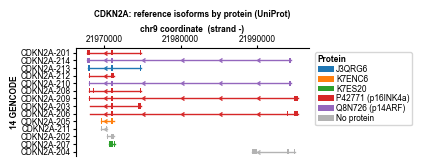

In [16]:
enst2protein = load_enst2protein(ensg)
if enst2protein is not None:
    print(pd.Series(enst2protein).value_counts())
else:
    print("No per-gene UniProt summary CSV -> reference shown in flat grey.")

_ = plot_gene_isoforms(GENE, ref, {}, {}, row=0.10, 
                       ref_group=enst2protein, lw = 1.0, arrow_lw= 1.0, arrow_size= 3.0,
                       title=(f"{GENE}: reference isoforms by protein (UniProt)"
                              if enst2protein is not None
                              else f"{GENE}: GENCODE reference isoforms"),
                       save=fig_path("reference_isoforms"), )

In [9]:
# To plot a different gene: set GENE in the Parameters cell at the top and re-run the notebook.
# (All sections + save paths derive from GENE.) To render just the reference for an ad-hoc gene
# without re-running everything, do it inline:
#
# g = "TP53"
# r, e = load_reference_models(g)
# print(f"{g}: {len(r)} GENCODE reference transcripts ({sorted(e)})")
# _ = plot_gene_isoforms(g, r, {}, {}, row=0.3,
#                        ref_group=load_enst2protein(e),
#                        title=f"{g}: GENCODE reference isoforms",
#                        save=f"{FIG_DIR}/{g.lower()}_reference_isoforms.pdf")

## 2. All PacBio isoforms

Reads the single global recollapsed collapse GFF (`pacbio/recollapsed/pooled/collapse.gff`) to get the canonical exon structure for each PacBio isoform of the gene. Fast (one file).

**Note:** some genes have long read-through / fusion isoforms (e.g. a `novel_not_in_catalog` extending far beyond the gene) that stretch the x-axis and squash the compact models. Filter to expressed isoforms (section 3) and/or clip the x-axis to the gene locus to read the real structures.

In [10]:
# reads the single global recollapsed collapse.gff (one canonical structure per PB id; fast)
pb, cat = load_pb_models(GENE, ensg)
print(f"{GENE}: {len(pb)} PacBio isoforms")
print(pd.Series([cat[t] for t in pb]).value_counts())

CDKN2A: 209 PacBio isoforms
novel_not_in_catalog       156
novel_in_catalog            35
full-splice_match           10
incomplete-splice_match      6
genic                        2
Name: count, dtype: int64


In [11]:
# _ = plot_gene_isoforms(GENE, ref, pb, cat, row=0.05,
#                        save=fig_path("all_isoforms"))

In [16]:
# --- Filter to isoforms expressed in >= MIN_CELLS cells --------------------------
# Per-PB.X.Y cell counts come from the pbids object's var["n_cells_by_counts"]
# (same source as notebook 04_01). We read only `var` via h5py, never the matrix.
import h5py

MIN_CELLS = 5   
MOL_H5AD  = "./../pacbio/h5ads/all_samples_pacbio_recollapsed_raw_counts_pbids_bc_anndata_preprocessed.h5ad"

def _decode(v):
    return np.array([x.decode() if isinstance(x, bytes) else x for x in v])

def load_pb_cell_counts(h5ad=MOL_H5AD):
    """PB.X.Y -> n_cells from the pbids-object var (reads only var, not X)."""
    with h5py.File(h5ad, "r") as f:
        var = f["var"]
        pb_ids = _decode(var[var.attrs["_index"]][:])
        o = var["n_cells_by_counts"]
        n = (pd.Categorical.from_codes(o["codes"][:], categories=_decode(o["categories"][:])).astype(float)
             if isinstance(o, h5py.Group) else np.asarray(o[:]))
    return dict(zip(pb_ids, n))

pb_counts = load_pb_cell_counts()
pb_expr = {t: m for t, m in pb.items() if pb_counts.get(t, 0) >= MIN_CELLS}
cat_expr = {t: cat[t] for t in pb_expr}
print(f"{GENE}: {len(pb_expr)} / {len(pb)} PacBio isoforms in >= {MIN_CELLS} cells")
print(pd.Series([cat_expr[t] for t in pb_expr]).value_counts())

CDKN2A: 27 / 209 PacBio isoforms in >= 5 cells
novel_not_in_catalog       12
full-splice_match           7
novel_in_catalog            7
incomplete-splice_match     1
Name: count, dtype: int64


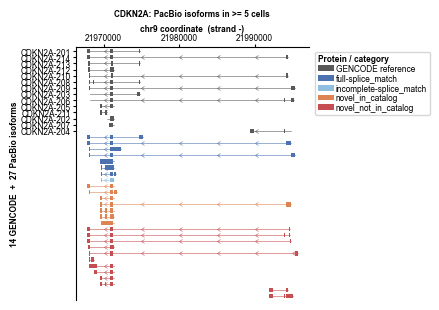

In [17]:
####Plot 
_ = plot_gene_isoforms(GENE, ref, pb_expr, cat_expr, row=0.08,
                       title=f"{GENE}: PacBio isoforms in >= {MIN_CELLS} cells",
                       save=fig_path(f"isoforms_min{MIN_CELLS}cells"))

### Zoomed to the p16/p14ARF core (optional)

389 isoforms is a dense stack. To read individual structures, subset — e.g. only the p16/p14ARF-annotated isoforms, only novel categories, or the most highly expressed. Example below keeps only isoforms whose full-splice / novel-in-catalog structure overlaps the CDKN2A protein-coding locus (chr9:21,967,000–21,995,000).

Novel CDKN2A isoforms in >= 5 cells: 19


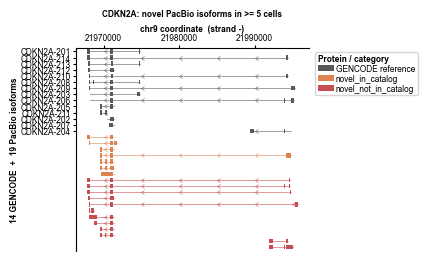

In [18]:
# Example subset: novel isoforms only (NIC + NNC) AND expressed in >= MIN_CELLS cells
novel = {"novel_in_catalog", "novel_not_in_catalog"}
pb_novel = {t: m for t, m in pb_expr.items() if cat_expr.get(t) in novel}
print(f"Novel {GENE} isoforms in >= {MIN_CELLS} cells: {len(pb_novel)}")
_ = plot_gene_isoforms(GENE, ref, pb_novel, cat_expr, row=0.08,
                       title=f"{GENE}: novel PacBio isoforms in >= {MIN_CELLS} cells",
                       save=fig_path(f"novel_isoforms_min{MIN_CELLS}cells"))

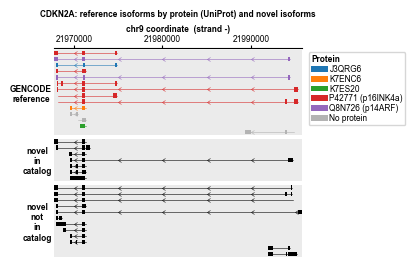

In [19]:
# Example: Figure-3-style grouped plot for the current GENE (reference coloured by protein,
# PacBio isoforms grouped into category bands). Swap pb_novel/cat_expr for pb_expr/cat_expr
# to show all expressed PacBio isoforms, or {} , {} for reference only.
_ = plot_gene_isoforms_grouped(
    GENE, ref, pb_novel, cat_expr, row=0.08,
    ref_group=enst2protein,
    title=(f"{GENE}: reference isoforms by protein (UniProt) and novel isoforms"
           if enst2protein is not None else f"{GENE}: isoforms by structural category"),
    save=fig_path("isoforms_grouped_by_category"),
)

## Highlight: multi-cell-type novel (NNC) CDKN2A isoforms

Two novel-not-in-catalog (NNC) CDKN2A isoforms stand out in notebook 06_02 (section 3) because they are expressed **broadly across cell types**, unlike the other NNC isoforms which are largely male-germ-cell / testis specific:

- **PB.100940.3354** - 17 cell types, 160 cells, 182 molecules (top: t cell)
- **PB.100940.3373** - 12 cell types, 35 cells, 37 molecules (top: fibroblast)

Both are NNC yet encode the known p16 shared-exon-2 ORF. Plotted below against the GENCODE p16/p14ARF reference models.

Highlighting: {'PB.100940.3354': 'novel_not_in_catalog', 'PB.100940.3373': 'novel_not_in_catalog'}


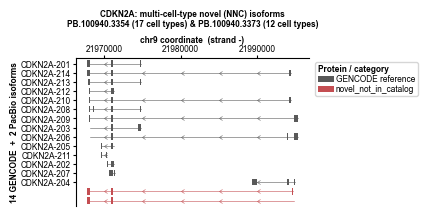

In [20]:
# Highlight the two broadly-expressed novel-not-in-catalog (NNC) CDKN2A isoforms from 06_02 sec 3.
#   PB.100940.3354 - 17 cell types, 160 cells, 182 molecules (top: t cell)
#   PB.100940.3373 - 12 cell types,  35 cells,  37 molecules (top: fibroblast)
HIGHLIGHT_PB = ["PB.100940.3354", "PB.100940.3373"]

missing = [t for t in HIGHLIGHT_PB if t not in pb]
if missing:
    print("WARNING: not found in recollapsed collapse.gff:", missing)
pb_hl  = {t: pb[t] for t in HIGHLIGHT_PB if t in pb}
cat_hl = {t: cat[t] for t in pb_hl}
print("Highlighting:", cat_hl)

_ = plot_gene_isoforms(
    GENE, ref, pb_hl, cat_hl, row=0.12,
    title=f"{GENE}: multi-cell-type novel (NNC) isoforms\n"
          f"PB.100940.3354 (17 cell types) & PB.100940.3373 (12 cell types)",
    save=fig_path("nnc_multicelltype_highlight"),
)